In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
FILE_PATH = '/content/drive/MyDrive/AIO 2024/Module_4/Week 2/CN/Data/BTC-Daily.csv'

In [ ]:
df = pd.read_csv(FILE_PATH)
df.head()

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
1,1646006400,2022-02-28 00:00:00,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2,1645920000,2022-02-27 00:00:00,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
3,1645833600,2022-02-26 00:00:00,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
4,1645747200,2022-02-25 00:00:00,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


# **Lấy thông tin bộ dữ liệu**

In [ ]:
df.describe()

,unix,open,high,low,close,Volume BTC,Volume USD
count,2.651000e+03,2651.000000,2651.000000,2651.000000,2651.000000,2.651000e+03,2.651000e+03
mean,1.531613e+09,11693.189332,12038.562912,11296.539461,11709.326213,1.330041e+07,6.099369e+07
std,6.613247e+07,16272.554746,16739.237000,15718.297511,16282.908704,4.715366e+07,1.072838e+08
min,1.417133e+09,162.000000,212.840000,152.400000,162.000000,0.000000e+00,0.000000e+00
25%,1.474373e+09,654.680000,664.460000,640.050000,654.370000,5.357883e+03,9.516170e+03
50%,1.531613e+09,6408.950000,6540.000000,6312.000000,6407.770000,1.503310e+04,2.288982e+07
75%,1.588853e+09,10708.620000,10956.240000,10303.755000,10726.425000,3.435336e+06,8.018383e+07
max,1.646093e+09,67547.490000,69000.000000,66250.000000,67559.000000,7.723295e+08,1.446125e+09


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2651 entries, 0 to 2650
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unix        2651 non-null   int64  
 1   date        2651 non-null   object 
 2   symbol      2651 non-null   object 
 3   open        2651 non-null   float64
 4   high        2651 non-null   float64
 5   low         2651 non-null   float64
 6   close       2651 non-null   float64
 7   Volume BTC  2651 non-null   float64
 8   Volume USD  2651 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 186.5+ KB


In [ ]:
# Range of dates process
df['date'] = pd.to_datetime(df['date'])
date_range = str(df['date'].dt.date.min()) + ' to ' +str(df['date'].dt.date.max())
print(date_range)

2014-11-28 to 2022-03-01


In [ ]:
df

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01,BTC/USD,43221.71,43626.49,43185.48,43185.48,4.900629e+01,2.116360e+06
1,1646006400,2022-02-28,BTC/USD,37717.10,44256.08,37468.99,43178.98,3.160618e+03,1.364723e+08
2,1645920000,2022-02-27,BTC/USD,39146.66,39886.92,37015.74,37712.68,1.701817e+03,6.418008e+07
3,1645833600,2022-02-26,BTC/USD,39242.64,40330.99,38600.00,39146.66,9.127241e+02,3.573010e+07
4,1645747200,2022-02-25,BTC/USD,38360.93,39727.97,38027.61,39231.64,2.202852e+03,8.642149e+07
...,...,...,...,...,...,...,...,...,...
2646,1417478400,2014-12-02,BTC/USD,378.39,382.86,375.23,379.25,2.593576e+06,6.832530e+03
2647,1417392000,2014-12-01,BTC/USD,376.40,382.31,373.03,378.39,2.520662e+06,6.660560e+03
2648,1417305600,2014-11-30,BTC/USD,376.57,381.99,373.32,373.34,1.145567e+06,3.046330e+03
2649,1417219200,2014-11-29,BTC/USD,376.42,386.60,372.25,376.72,2.746157e+06,7.245190e+03


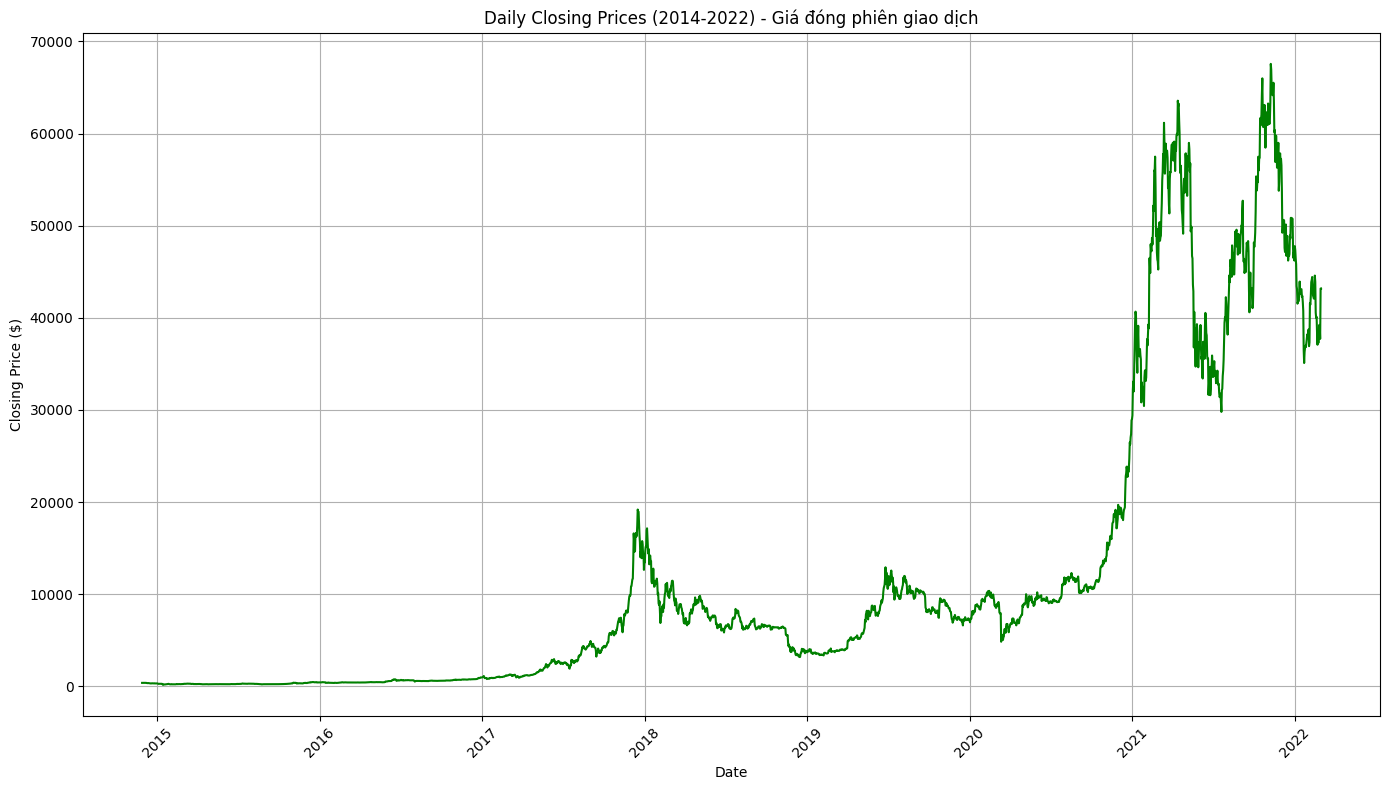

In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(df['date'], df['close'], linestyle='-', color='g')
plt.title('Daily Closing Prices (2014-2022) - Giá đóng phiên giao dịch')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Converting Date to numerical form - chuyển value Feature date - > Dạng số

df['date_str'] = df['date'].dt.strftime('%Y%m%d%H%M%S')

# Convert the string date to a numerical value
df['NumericalDate'] = pd.to_numeric(df['date_str'])

# Drop the intermediate 'date_str' column if not needed
df.drop(columns=['date_str'], inplace=True)

In [ ]:
df['NumericalDate']

,NumericalDate
0,20220301000000
1,20220228000000
2,20220227000000
3,20220226000000
4,20220225000000
...,...
2646,20141202000000
2647,20141201000000
2648,20141130000000
2649,20141129000000


In [ ]:
# chuẩn hóa DL để huấn luyện Mô hình
# Lấy các đặc trưng cần thiết để huấn luyện mô hinh
scaler = StandardScaler()

In [ ]:
df['standard_high_price'] = scaler.fit_transform(df[['high']])
df['standard_low_price'] = scaler.fit_transform(df[['low']])
df['standard_open_price'] = scaler.fit_transform(df[['open']])
df['standard_close_price'] = scaler.fit_transform(df[['close']])

# **Sử dụng mô hình Linear Regression của sklearn**

In [ ]:
X = df[['NumericalDate','standard_high_price', 'standard_low_price', 'standard_open_price']]
y = df['standard_close_price']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

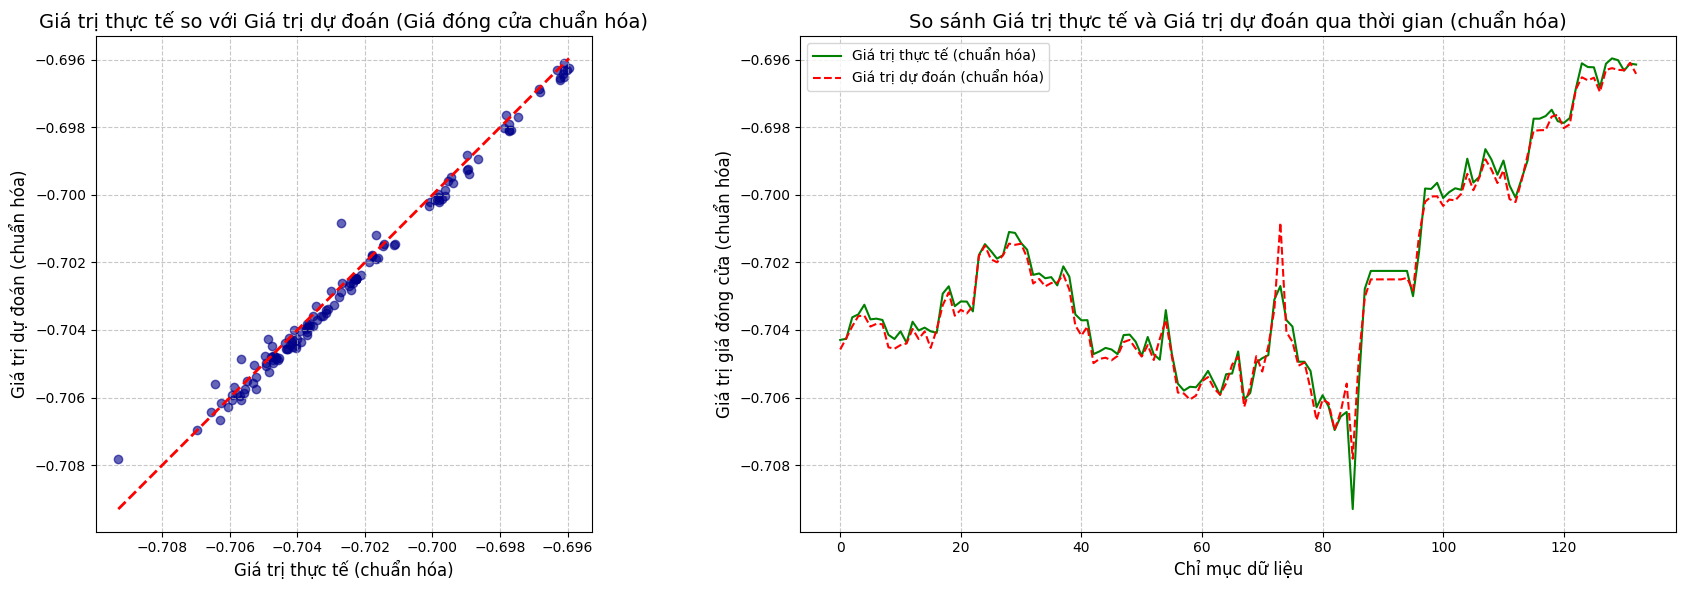

In [ ]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Scatter plot of Actual vs. Predicted values
axes[0].scatter(y_test, y_pred, alpha=0.6, color='darkblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Giá trị thực tế so với Giá trị dự đoán (Giá đóng cửa chuẩn hóa)', fontsize=14)
axes[0].set_xlabel('Giá trị thực tế (chuẩn hóa)', fontsize=12)
axes[0].set_ylabel('Giá trị dự đoán (chuẩn hóa)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_aspect('equal', adjustable='box') # Make axes scales equal

# Subplot 2: Line plot of Actual vs. Predicted values over index
# For better visualization, we can sort y_test by its index
# or simply plot them in the order they appear

# To make the plot more readable, we can take a sample or plot them in the order they appear.
# For now, let's plot them as they are, indexed.

# Convert y_test and y_pred to pandas Series for easier plotting with index
y_test_series = pd.Series(y_test).reset_index(drop=True)
y_pred_series = pd.Series(y_pred).reset_index(drop=True)

axes[1].plot(y_test_series.index, y_test_series, label='Giá trị thực tế (chuẩn hóa)', color='green', linewidth=1.5)
axes[1].plot(y_pred_series.index, y_pred_series, label='Giá trị dự đoán (chuẩn hóa)', color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('So sánh Giá trị thực tế và Giá trị dự đoán qua thời gian (chuẩn hóa)', fontsize=14)
axes[1].set_xlabel('Chỉ mục dữ liệu', fontsize=12)
axes[1].set_ylabel('Giá trị giá đóng cửa (chuẩn hóa)', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **Model Linear implementation**

In [ ]:
# Nên chuyển về vector dạng cột -> chuyển về dạng ma trận N dòng 1 cột -> Chuẩn với toán học
class LinearRegression:
    def __init__(self,lr = 0.01, batch_size = 1, epochs = 100, shuffle = False):
        self.lr = lr # learning rate
        self.batch_size = batch_size # num sample to training
        self.epochs = epochs # epoch: Number of times the model is learned in all data
        self.shuffle = shuffle # allow shuffle data in each epoch
        self.w = None
        self.Nfeature = None # number of feature of data train
        self.Nsample = None # number of sample of data train
        self.Losses = [] # List of loss of each epoch
    def checkDim(self,X):
        if X.ndim == 1:
            raise ValueError("X must be 2 Dimensional")
        return 1
    # add feature have value = 1 on head each sample
    def addfeature1(self,X):
        if self.checkDim(X):
            if X.shape[1] == self.Nfeature + 1: return X
            else:
                feature1 = np.ones(X.shape[0]).reshape(-1,1)
                return np.concatenate((feature1,X),axis = 1)
    # function predict
    def predict(self,X):
        X = self.addfeature1(X)
        return X@self.w

    # Compute Loss
    def compute_loss(self,y_pred,y):
        return np.mean((y_pred-y)**2)/2

    # Compute gradient Loss with w
    # Loss = 1/2m *(y_pred-y)^2 -> m is bacth_size
    def dL_dw(self,y_pred,y,X):
        return X.T@(y_pred - y)*1/X.shape[0] # / for X.shape[0] because the sample of X != batch_size

    # function training model
    def fit(self,X,y):
        self.Nsample, self.Nfeature = X.shape
        # add feature 1 for X
        X = self.addfeature1(X)
        y = y.reshape(-1,1)
        self.w = np.random.uniform(-1,1,size= self.Nfeature+1).reshape(-1,1)# w is matrix have shape (Nfeatur,1)
        data_train = np.concatenate((X,y),axis = 1)
        for epoch in range(self.epochs):
            if self.shuffle: np.random.shuffle(data_train)
            Loss = [] # Loss of 1 epoch
            for i in range(0,self.Nsample,self.batch_size):
                batch = data_train[i:i+self.batch_size]
                X_train, ytrain = batch[:,:-1], batch[:,-1].reshape(-1,1)
                y_pred = self.predict(X_train)
                loss = self.compute_loss(y_pred,ytrain)
                Loss.append(loss) # append loss of each batch
                dL_dw = self.dL_dw(y_pred,ytrain,X_train)
                self.w -= self.lr*dL_dw
            self.Losses.append(sum(Loss)/len(Loss))
            print(f"epoch: {epoch+1:<5} ====== Loss = {self.Losses[-1].item():<10.4f} =============== w = {str(self.w.reshape(1,-1)):<20}")

In [ ]:
X = df[['standard_high_price', 'standard_low_price', 'standard_open_price']].to_numpy()
y = df['standard_close_price'].to_numpy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

In [ ]:
rg = LinearRegression(lr=0.01,batch_size=X_train.shape[0],epochs=500,shuffle=True)
rg.fit(X_train,y_train)

epoch: 1     ====== Loss = 0.5428     =============== w = [[-0.03953126  0.8080021   0.80752826  0.38455604]]
epoch: 2     ====== Loss = 0.5103     =============== w = [[-0.03913731  0.79783468  0.79735537  0.37438165]]
epoch: 3     ====== Loss = 0.4797     =============== w = [[-0.0387473   0.78797727  0.78749261  0.3645173 ]]
epoch: 4     ====== Loss = 0.4509     =============== w = [[-0.03836117  0.77842041  0.77793052  0.35495356]]
epoch: 5     ====== Loss = 0.4239     =============== w = [[-0.0379789   0.76915495  0.76865994  0.34568125]]
epoch: 6     ====== Loss = 0.3985     =============== w = [[-0.03760043  0.760172    0.75967199  0.3366915 ]]
epoch: 7     ====== Loss = 0.3746     =============== w = [[-0.03722574  0.75146296  0.75095804  0.32797569]]
epoch: 8     ====== Loss = 0.3522     =============== w = [[-0.03685479  0.74301946  0.74250974  0.31952546]]
epoch: 9     ====== Loss = 0.3311     =============== w = [[-0.03648753  0.73483343  0.73431901  0.31133273]]
epoch: 10 

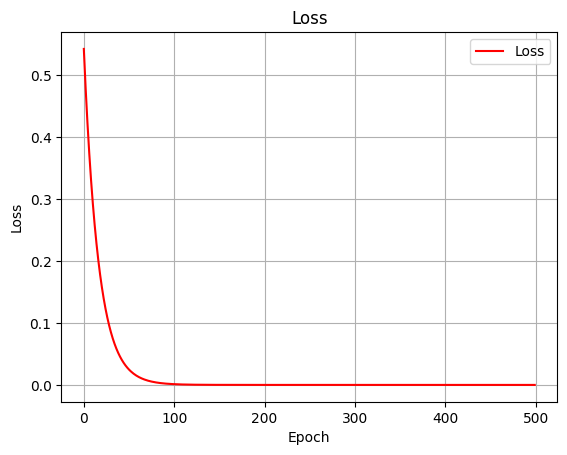

In [ ]:
plt.title("Loss")
plt.plot(rg.Losses,label = "Loss", color = 'r')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [63]:
# Sử dụng R2-score để đánh giá độ chính xác của mô hình
from sklearn.metrics import r2_score, mean_squared_error,root_mean_squared_error
y_pred = rg.predict(X_test)
train_accuracy = r2_score(y_train, rg.predict(X_train))
test_accuracy = r2_score(y_test, y_pred)
# Căn bậc hai của mean_square_error
print("Root Mean Square Error(RMSE):", root_mean_squared_error(y_test, y_pred))
print("Mean Square Error(MSE):", mean_squared_error(y_test, y_pred))
print("R2-score on training set:", round(train_accuracy,4))
print("R2-score on test set:", round(test_accuracy,4))

Root Mean Square Error(RMSE): 0.023836322465338816
Mean Square Error(MSE): 0.0005681702686716159
R2-score on training set: 0.9993
R2-score on test set: 0.9994
